In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/dog-and-cat-classification-dataset/PetImages/Dog/7981.jpg
/kaggle/input/dog-and-cat-classification-dataset/PetImages/Dog/6234.jpg
/kaggle/input/dog-and-cat-classification-dataset/PetImages/Dog/1269.jpg
/kaggle/input/dog-and-cat-classification-dataset/PetImages/Dog/3863.jpg
/kaggle/input/dog-and-cat-classification-dataset/PetImages/Dog/6241.jpg
/kaggle/input/dog-and-cat-classification-dataset/PetImages/Dog/10304.jpg
/kaggle/input/dog-and-cat-classification-dataset/PetImages/Dog/623.jpg
/kaggle/input/dog-and-cat-classification-dataset/PetImages/Dog/2193.jpg
/kaggle/input/dog-and-cat-classification-dataset/PetImages/Dog/11925.jpg
/kaggle/input/dog-and-cat-classification-dataset/PetImages/Dog/3750.jpg
/kaggle/input/dog-and-cat-classification-dataset/PetImages/Dog/11378.jpg
/kaggle/input/dog-and-cat-classification-dataset/PetImages/Dog/2008.jpg
/kaggle/input/dog-and-cat-classification-dataset/PetImages/Dog/10730.jpg
/kaggle/input/dog-and-cat-classification-dataset/PetImages/Do

In [2]:
import cv2 as cv

image_path = []
pet_label = []
for dirname,_,filenames in os.walk('/kaggle/input/dog-and-cat-classification-dataset/PetImages'):
    for filename in filenames:
        # print(os.path.join(dirname,filename))
        name = os.path.join(dirname,filename)
        image_path.append(name)
        
        className = name.split('/')[-2]
        pet_label.append(className)
        # print(f'Class name: {className}')
        


In [3]:
data = {
    'image': image_path,
    'label': pet_label
}

df = pd.DataFrame(data)

In [4]:
df.tail()

,image,label
24993,/kaggle/input/dog-and-cat-classification-datas...,Cat
24994,/kaggle/input/dog-and-cat-classification-datas...,Cat
24995,/kaggle/input/dog-and-cat-classification-datas...,Cat
24996,/kaggle/input/dog-and-cat-classification-datas...,Cat
24997,/kaggle/input/dog-and-cat-classification-datas...,Cat


In [5]:
df['label'].value_counts()

label
Dog    12499
Cat    12499
Name: count, dtype: int64

In [6]:
import torch
import torch.nn as nn
from torch.utils.data import Dataset,DataLoader
from torchvision import transforms,models
from PIL import Image
import matplotlib.pyplot as plt
from tqdm.notebook import tqdm
import torch.nn.init as init

In [7]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


In [8]:
## validating images 
def is_valid_image(path):
    try:
        img = Image.open(path)
        img.verify()
        return True
    except (IOError,SyntaxError) as e:
        return False

print(f"Original Dataframe size: {len(df)}")
df['is_valid'] = df['image'].apply(is_valid_image)
df_cleaned = df[df['is_valid']].drop(columns=['is_valid'])
print(f"Cleaned Dataframe size: {len(df_cleaned)}")

Original Dataframe size: 24998


/usr/local/lib/python3.11/dist-packages/PIL/TiffImagePlugin.py:949: UserWarning: Truncated File Read
  warnings.warn(str(msg))


Cleaned Dataframe size: 24998


In [9]:
df_cleaned.sample(5)

,image,label
8655,/kaggle/input/dog-and-cat-classification-datas...,Dog
14497,/kaggle/input/dog-and-cat-classification-datas...,Cat
22547,/kaggle/input/dog-and-cat-classification-datas...,Cat
7254,/kaggle/input/dog-and-cat-classification-datas...,Dog
322,/kaggle/input/dog-and-cat-classification-datas...,Dog


In [10]:
from sklearn.model_selection import train_test_split

label_mapping = {'Dog':0,'Cat':1}
df_cleaned['label_id'] = df_cleaned['label'].map(label_mapping)

train_df,valid_df = train_test_split(df_cleaned,test_size=0.2,random_state=42,stratify=df_cleaned['label_id'])

In [11]:
df_cleaned.sample(10)

,image,label,label_id
3103,/kaggle/input/dog-and-cat-classification-datas...,Dog,0
8133,/kaggle/input/dog-and-cat-classification-datas...,Dog,0
9097,/kaggle/input/dog-and-cat-classification-datas...,Dog,0
19140,/kaggle/input/dog-and-cat-classification-datas...,Cat,1
7539,/kaggle/input/dog-and-cat-classification-datas...,Dog,0
19055,/kaggle/input/dog-and-cat-classification-datas...,Cat,1
22310,/kaggle/input/dog-and-cat-classification-datas...,Cat,1
24100,/kaggle/input/dog-and-cat-classification-datas...,Cat,1
15253,/kaggle/input/dog-and-cat-classification-datas...,Cat,1
11157,/kaggle/input/dog-and-cat-classification-datas...,Dog,0


In [12]:
train_df.shape

(19998, 3)

In [13]:
valid_df.shape

(5000, 3)

In [14]:
img = Image.open(df_cleaned['image'][0])
img.show()

In [15]:
img.size

(500, 375)

In [16]:
valid_df

,image,label,label_id
15625,/kaggle/input/dog-and-cat-classification-datas...,Cat,1
18777,/kaggle/input/dog-and-cat-classification-datas...,Cat,1
8927,/kaggle/input/dog-and-cat-classification-datas...,Dog,0
3998,/kaggle/input/dog-and-cat-classification-datas...,Dog,0
15286,/kaggle/input/dog-and-cat-classification-datas...,Cat,1
...,...,...,...
15171,/kaggle/input/dog-and-cat-classification-datas...,Cat,1
7987,/kaggle/input/dog-and-cat-classification-datas...,Dog,0
10276,/kaggle/input/dog-and-cat-classification-datas...,Dog,0
19336,/kaggle/input/dog-and-cat-classification-datas...,Cat,1


In [17]:
# Image Size for AlexNet
IMG_SIZE = 224

train_transforms = transforms.Compose([
    transforms.Resize((IMG_SIZE,IMG_SIZE)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485,0.456,0.406],std=[0.229,0.224,0.225])    
])

valid_transforms = transforms.Compose([
    transforms.Resize((IMG_SIZE,IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485,0.456,0.406],std=[0.229,0.224,0.225])        
])

In [18]:
len(train_df)

19998

In [19]:
class CustomDataset(Dataset):
    def __init__(self,df,transform=None):
        self.dataframe = df
        self.transform = transform

    def __len__(self):
        return len(self.dataframe)

    def __getitem__(self,idx):
        img_path = self.dataframe.iloc[idx]['image']
        label = self.dataframe.iloc[idx]['label_id']

        image = Image.open(img_path).convert('RGB')

        if self.transform:
            image = self.transform(image)
        return image,torch.tensor(label,dtype=torch.long)

In [20]:
## creating dataloaders
train_dataset = CustomDataset(df=train_df,transform=train_transforms)
val_dataset = CustomDataset(df=valid_df,transform=valid_transforms)

In [21]:
BATCH_SIZE = 32

train_dataloader = DataLoader(train_dataset,batch_size=BATCH_SIZE,shuffle=True,pin_memory=True)
val_dataloader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False,pin_memory=True)


In [22]:
print(f"Number of training batches: {len(train_dataloader)}")
print(f"Number of validation batches: {len(val_dataloader)}")

Number of training batches: 625
Number of validation batches: 157


In [23]:
# img,lab = next(iter(train_dataloader))

In [24]:
# img

In [25]:
## AlexNet Model
class AlexNet(nn.Module):
    def __init__(self,num_classes):
        super(AlexNet,self).__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3,96,kernel_size=11,stride=4,padding=0),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=3,stride=2),
            nn.Conv2d(96,256,kernel_size=5,stride=1,padding=2),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=3,stride=2),
            nn.Conv2d(256,384,kernel_size=3,stride=1,padding=1),
            nn.ReLU(inplace=True),
            nn.Conv2d(384,384,kernel_size=3,stride=1,padding=1),
            nn.ReLU(inplace=True),
            nn.Conv2d(384,256,kernel_size=3,stride=1,padding=1),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=3, stride=2)
        )

## classifier layers
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(256*5*5,4096),
            nn.ReLU(inplace=True),
            nn.Linear(4096,4096),
            nn.ReLU(inplace=True),
            nn.Linear(4096,1000),
            nn.ReLU(inplace=True),
            nn.Linear(1000,num_classes),
        )

        self._initialize_weights()

    def _initialize_weights(self):
        for m in self.modules():
            if isinstance(m,nn.Conv2d):
                init.kaiming_normal_(m.weight,mode='fan_out',nonlinearity='relu')
                if m.bias is not None:
                    init.constant_(m.bias,0)
            elif isinstance(m,nn.Linear):
                init.kaiming_normal_(m.weight, mode='fan_out', nonlinearity='relu')
                init.constant_(m.bias, 0)

    def forward(self,x):
        x = self.features(x)
        x = self.classifier(x)
        return x
        

In [35]:
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

def train_model(model, train_loader, criterion, optimizer, device, num_epochs=10):
    model.train()
    # train_losses = []
    # train_accuracies = []
    for epoch in range(num_epochs):
        running_loss = 0.0
        correct_predictions = 0
        total_samples = 0
        pbar = tqdm(train_loader, desc=f"Epoch {epoch+1}/{num_epochs} [TRAIN]")
        for images, labels in pbar:
            images = images.to(device)
            labels = labels.to(device)

            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            running_loss += loss.item() * images.size(0)
            _, predicted = torch.max(outputs.data, 1)
            total_samples += labels.size(0)
            correct_predictions += (predicted == labels).sum().item()
            pbar.set_postfix(loss=loss.item(), acc=correct_predictions/total_samples)

        epoch_loss = running_loss / total_samples
        epoch_accuracy = correct_predictions / total_samples
        # train_losses.append(epoch_loss)
        # train_accuracies.append(epoch_accuracy)
        print(f"Epoch {epoch+1} - Training Loss: {epoch_loss:.4f}, Training Accuracy: {epoch_accuracy:.4f}")


In [36]:
def evaluate_model(model, val_loader, criterion):
    model.eval()
    running_loss = 0.0
    correct_predictions = 0
    total_samples = 0
    all_labels = []
    all_predictions = []

    with torch.no_grad():
        pbar = tqdm(val_loader, desc="[EVALUATION]")
        for images, labels in pbar:
            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)
            loss = criterion(outputs, labels)

            running_loss += loss.item() * images.size(0)
            _, predicted = torch.max(outputs.data, 1)
            total_samples += labels.size(0)
            correct_predictions += (predicted == labels).sum().item()

            all_labels.extend(labels.cpu().numpy())
            all_predictions.extend(predicted.cpu().numpy())
            pbar.set_postfix(loss=loss.item(), acc=correct_predictions/total_samples)

    avg_loss = running_loss / total_samples
    accuracy = correct_predictions / total_samples

    print(f"\nValidation Loss: {avg_loss:.4f}, Validation Accuracy: {accuracy:.4f}")

    print("\nClassification Report:")
    print(classification_report(all_labels, all_predictions, target_names=['Dog', 'Cat']))

    print("\nConfusion Matrix:")
    cm = confusion_matrix(all_labels, all_predictions)
    print(cm)

    plt.figure(figsize=(6, 5))
    import seaborn as sns
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Dog', 'Cat'], yticklabels=['Dog', 'Cat'])
    plt.xlabel('Predicted')
    plt.ylabel('True')
    plt.title('Confusion Matrix')
    plt.show()

    return accuracy, avg_loss


--- Starting Training ---


Epoch 1/10 [TRAIN]:   0%|          | 0/625 [00:00<?, ?it/s]

Epoch 1 - Training Loss: 0.9853, Training Accuracy: 0.6628


Epoch 2/10 [TRAIN]:   0%|          | 0/625 [00:00<?, ?it/s]

Epoch 2 - Training Loss: 0.5252, Training Accuracy: 0.7428


...

Epoch 9 - Training Loss: 0.2592, Training Accuracy: 0.8896


Epoch 10/10 [TRAIN]:   0%|          | 0/625 [00:00<?, ?it/s]

Epoch 10 - Training Loss: 0.2470, Training Accuracy: 0.8946

--- Starting Evaluation ---


[EVALUATION]:   0%|          | 0/157 [00:00<?, ?it/s]


Validation Loss: 0.2641, Validation Accuracy: 0.8952

Classification Report:
              precision    recall  f1-score   support

         Dog       0.88      0.92      0.90      2500
         Cat       0.91      0.87      0.89      2500

    accuracy                           0.90      5000
   macro avg       0.90      0.90      0.90      5000
weighted avg       0.90      0.90      0.90      5000


Confusion Matrix:
[[2290  210]
 [ 314 2186]]


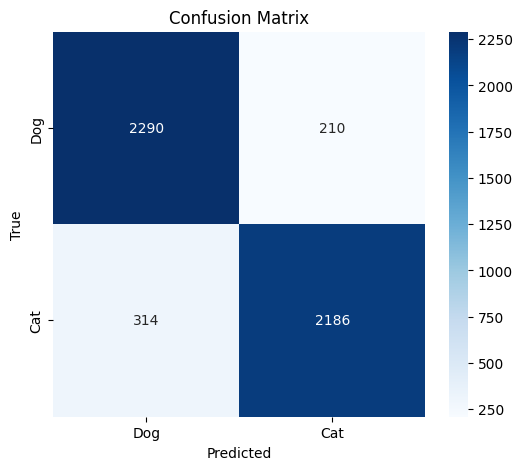

In [37]:

# Instantiate the AlexNet model
num_classes = 2 # Cat and Dog
alexnet_model = AlexNet(num_classes=num_classes).to(device)

# Define Loss function and Optimizer
criterion = nn.CrossEntropyLoss() # Suitable for multi-class classification
optimizer = torch.optim.Adam(alexnet_model.parameters(), lr=0.0001) # Adam optimizer is a good choice

# Number of epochs
NUM_EPOCHS = 10

print("\n--- Starting Training ---")
train_model(alexnet_model, train_dataloader, criterion, optimizer,device, num_epochs=NUM_EPOCHS)

print("\n--- Starting Evaluation ---")
val_accuracy, val_loss = evaluate_model(alexnet_model, val_dataloader, criterion)


In [38]:
## Adding 2 more CNN layers to AlexNet
class AlexNet2(nn.Module):
    def __init__(self,num_classes):
        super(AlexNet2,self).__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3,96,kernel_size=11,stride=4,padding=0),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=3,stride=2),
            nn.Conv2d(96,256,kernel_size=5,stride=1,padding=2),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=3,stride=2),
            nn.Conv2d(256,384,kernel_size=3,stride=1,padding=1),
            nn.ReLU(inplace=True),
            nn.Conv2d(384,384,kernel_size=3,stride=1,padding=1),
            nn.ReLU(inplace=True),
            nn.Conv2d(384,256,kernel_size=3,stride=1,padding=1),
            nn.ReLU(inplace=True),

            ## adding more layers here
            nn.Conv2d(256,512,kernel_size=3,stride=1,padding=1),
            nn.ReLU(inplace=True),
            nn.Conv2d(512,256,kernel_size=3,stride=1,padding=1),
            nn.ReLU(inplace=True),
            
            nn.MaxPool2d(kernel_size=3, stride=2)
            
        )

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(256*5*5,4096),
            nn.ReLU(inplace=True),
            nn.Linear(4096,4096),
            nn.ReLU(inplace=True),
            nn.Linear(4096,1000),
            nn.ReLU(inplace=True),
            nn.Linear(1000,num_classes),
        )        
        self._initialize_weights()

    def _initialize_weights(self):
        for m in self.modules():
            if isinstance(m,nn.Conv2d):
                init.kaiming_normal_(m.weight,mode='fan_out',nonlinearity='relu')
                if m.bias is not None:
                    init.constant_(m.bias,0)
            elif isinstance(m,nn.Linear):
                init.kaiming_normal_(m.weight, mode='fan_out', nonlinearity='relu')
                init.constant_(m.bias, 0)

    def forward(self,x):
        x = self.features(x)
        x = self.classifier(x)
        return x

In [ ]:

# Instantiate the AlexNet model
# num_classes = 2 # Cat and Dog
alexnet_model2 = AlexNet2(num_classes=num_classes).to(device)

# Define Loss function and Optimizer
criterion = nn.CrossEntropyLoss() # Suitable for multi-class classification
optimizer = torch.optim.Adam(alexnet_model2.parameters(), lr=0.0001) # Adam optimizer is a good choice

# Number of epochs
NUM_EPOCHS = 10

print("\n--- Starting Training ---")
train_model(alexnet_model2, train_dataloader, criterion, optimizer,device, num_epochs=NUM_EPOCHS)

print("\n--- Starting Evaluation ---")
val_accuracy, val_loss = evaluate_model(alexnet_model2, val_dataloader, criterion)



--- Starting Training ---


Epoch 1/10 [TRAIN]:   0%|          | 0/625 [00:00<?, ?it/s]

Epoch 1 - Training Loss: 0.9571, Training Accuracy: 0.6595


Epoch 2/10 [TRAIN]:   0%|          | 0/625 [00:00<?, ?it/s]

Epoch 2 - Training Loss: 0.5290, Training Accuracy: 0.7383


...

Epoch 8/10 [TRAIN]:   0%|          | 0/625 [00:00<?, ?it/s]

Epoch 8 - Training Loss: 0.2712, Training Accuracy: 0.8832


Epoch 9/10 [TRAIN]:   0%|          | 0/625 [00:00<?, ?it/s]

Epoch 9 - Training Loss: 0.2561, Training Accuracy: 0.8897


Epoch 10/10 [TRAIN]:   0%|          | 0/625 [00:00<?, ?it/s]

[EVALUATION]:   0%|          | 0/157 [00:00<?, ?it/s]


Validation Loss: 0.3122, Validation Accuracy: 0.8728

Classification Report:
              precision    recall  f1-score   support

         Dog       0.82      0.96      0.88      2500
         Cat       0.95      0.78      0.86      2500

    accuracy                           0.87      5000
   macro avg       0.89      0.87      0.87      5000
weighted avg       0.89      0.87      0.87      5000


Confusion Matrix:
[[2407   93]
 [ 543 1957]]


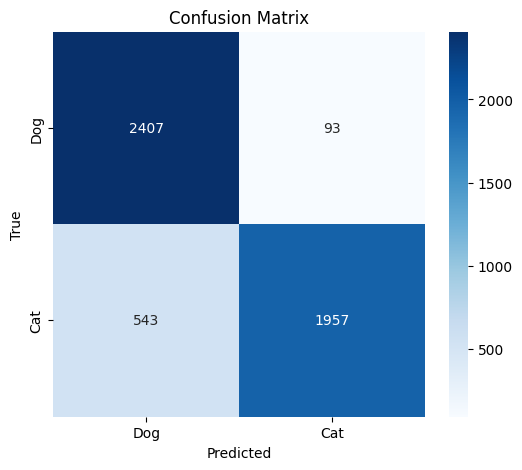

In [64]:
val_accuracy, val_loss = evaluate_model(alexnet_model2, val_dataloader, criterion)

In [42]:
inv_label_mapping = {v:k for k,v in label_mapping.items()}

In [49]:
def visualize_model(model,num_images=6):
    was_training = model.training
    model.eval()
    images_so_far = 0
    fig = plt.figure()

    with torch.no_grad():
        for i,(inputs,labels) in enumerate(val_dataloader):
            inputs = inputs.to(device)
            labels = labels.to(device)

            outputs = model(inputs)
            _,preds = torch.max(outputs,1)

            for j in range(inputs.size(0)):
                images_so_far += 1
                ax = plt.subplot(num_images//2,2,images_so_far)
                ax.axis('off')
                ax.set_title(f'predicted: {inv_label_mapping[preds[j].item()]}')
                plt.imshow(inputs.cpu().data[j].permute(1,2,0))

                if images_so_far == num_images:
                    model.train(mode=was_training)
                    return

            model.train(mode=was_training)


In [50]:
device

device(type='cuda')

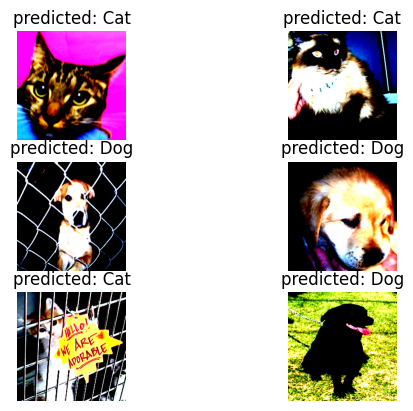

In [51]:
visualize_model(alexnet_model2)

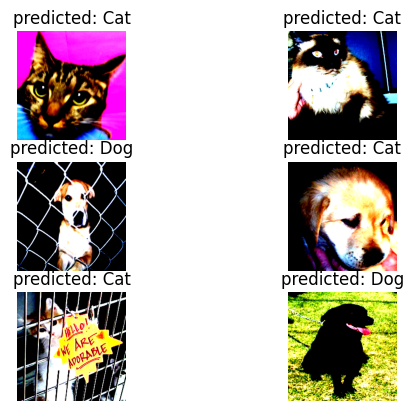

In [52]:
visualize_model(alexnet_model)

### Transfer Learning from ResNet18 model for Cat and Dog Classification

In [57]:
import torchvision
model_ft = torchvision.models.resnet18(weights='IMAGENET1K_V1')

In [58]:
model_ft

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
  

In [59]:
num_ftrs = model_ft.fc.in_features
model_ft.fc = nn.Linear(num_ftrs,num_classes)
model_ft = model_ft.to(device)
criterion = nn.CrossEntropyLoss()
optimizer_ft = torch.optim.Adam(model_ft.parameters(), lr=0.001) # Adam optimizer is a good choice

# Decay LR by a factor of 0.1 every 7 epochs
exp_lr_scheduler = torch.optim.lr_scheduler.StepLR(optimizer_ft,step_size=7,gamma=0.1)


In [60]:
train_model(model_ft, train_dataloader, criterion, optimizer_ft,device, num_epochs=NUM_EPOCHS)

Epoch 1/10 [TRAIN]:   0%|          | 0/625 [00:00<?, ?it/s]

/usr/local/lib/python3.11/dist-packages/PIL/TiffImagePlugin.py:949: UserWarning: Truncated File Read
  warnings.warn(str(msg))


Epoch 1 - Training Loss: 0.1772, Training Accuracy: 0.9264


Epoch 2/10 [TRAIN]:   0%|          | 0/625 [00:00<?, ?it/s]

Epoch 2 - Training Loss: 0.1242, Training Accuracy: 0.9489


...

Epoch 8 - Training Loss: 0.0718, Training Accuracy: 0.9709


Epoch 9/10 [TRAIN]:   0%|          | 0/625 [00:00<?, ?it/s]

Epoch 9 - Training Loss: 0.0660, Training Accuracy: 0.9742


Epoch 10/10 [TRAIN]:   0%|          | 0/625 [00:00<?, ?it/s]

Epoch 10 - Training Loss: 0.0659, Training Accuracy: 0.9741


[EVALUATION]:   0%|          | 0/157 [00:00<?, ?it/s]


Validation Loss: 0.0889, Validation Accuracy: 0.9650

Classification Report:
              precision    recall  f1-score   support

         Dog       0.98      0.95      0.96      2500
         Cat       0.95      0.98      0.97      2500

    accuracy                           0.96      5000
   macro avg       0.97      0.96      0.96      5000
weighted avg       0.97      0.96      0.96      5000


Confusion Matrix:
[[2375  125]
 [  50 2450]]


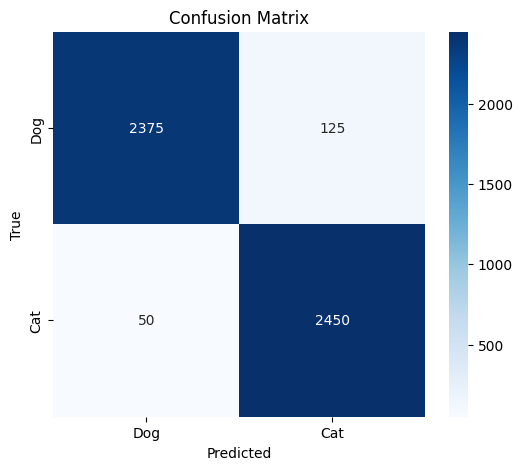

In [63]:
val_accuracy, val_loss = evaluate_model(model_ft, val_dataloader, criterion)

| Model                  | Accuracy | Key Issue                              |
| ---------------------- | -------- | -------------------------------------- |
| **ResNet18**           | 96.5%    | Near perfect, both classes balanced    |
| **AlexNet (original)** | 89.5%    | Some confusion, but fairly balanced    |
| **AlexNet +2 conv**    | 87.3%    | Overcomplicated, confused on cat class |
